# Homework 2 — DSCI 552

Combined Cycle Power Plant regression, plus ISLR conceptual exercises 2.4.1 and 2.4.7.

The plant file stores ambient temperature as `AT` and net energy output as `PE`. In the prompt those variables are called T and EP. Every model below uses Sheet 1 only. Statistical tests use a significance level of 0.05.

## 1. Combined Cycle Power Plant

### (a) Data

The Combined Cycle Power Plant file is already in `CCPP/Folds5x2_pp.xlsx`. It has five sheets. Each sheet is the same 9,568 hourly records in a different shuffle. The assignment says to work with Sheet 1, so the other sheets are not used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

DATA_PATH = "CCPP/Folds5x2_pp.xlsx"
PREDICTORS = ["AT", "V", "AP", "RH"]
TARGET = "PE"
ALPHA = 0.05
RANDOM_STATE = 42

df = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### (b.i) What the rows and columns are

In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("Column names:", list(df.columns))
print("Missing values:")
print(df.isna().sum())

Rows: 9568
Columns: 5
Column names: ['AT', 'V', 'AP', 'RH', 'PE']
Missing values:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


Sheet 1 has **9,568 rows and 5 columns**, and no missing values.

Each row is one hour of full-load operation between 2006 and 2011. The columns are:

| Column | Meaning | Unit |
|---|---|---|
| AT | Ambient temperature (T in the prompt) | °C |
| V | Exhaust vacuum | cm Hg |
| AP | Ambient pressure | mbar |
| RH | Relative humidity | % |
| PE | Net hourly electrical energy output (EP in the prompt) | MW |

AT, V, AP, and RH are the predictors. PE is the response.

#### (b.ii) Pairwise scatterplots

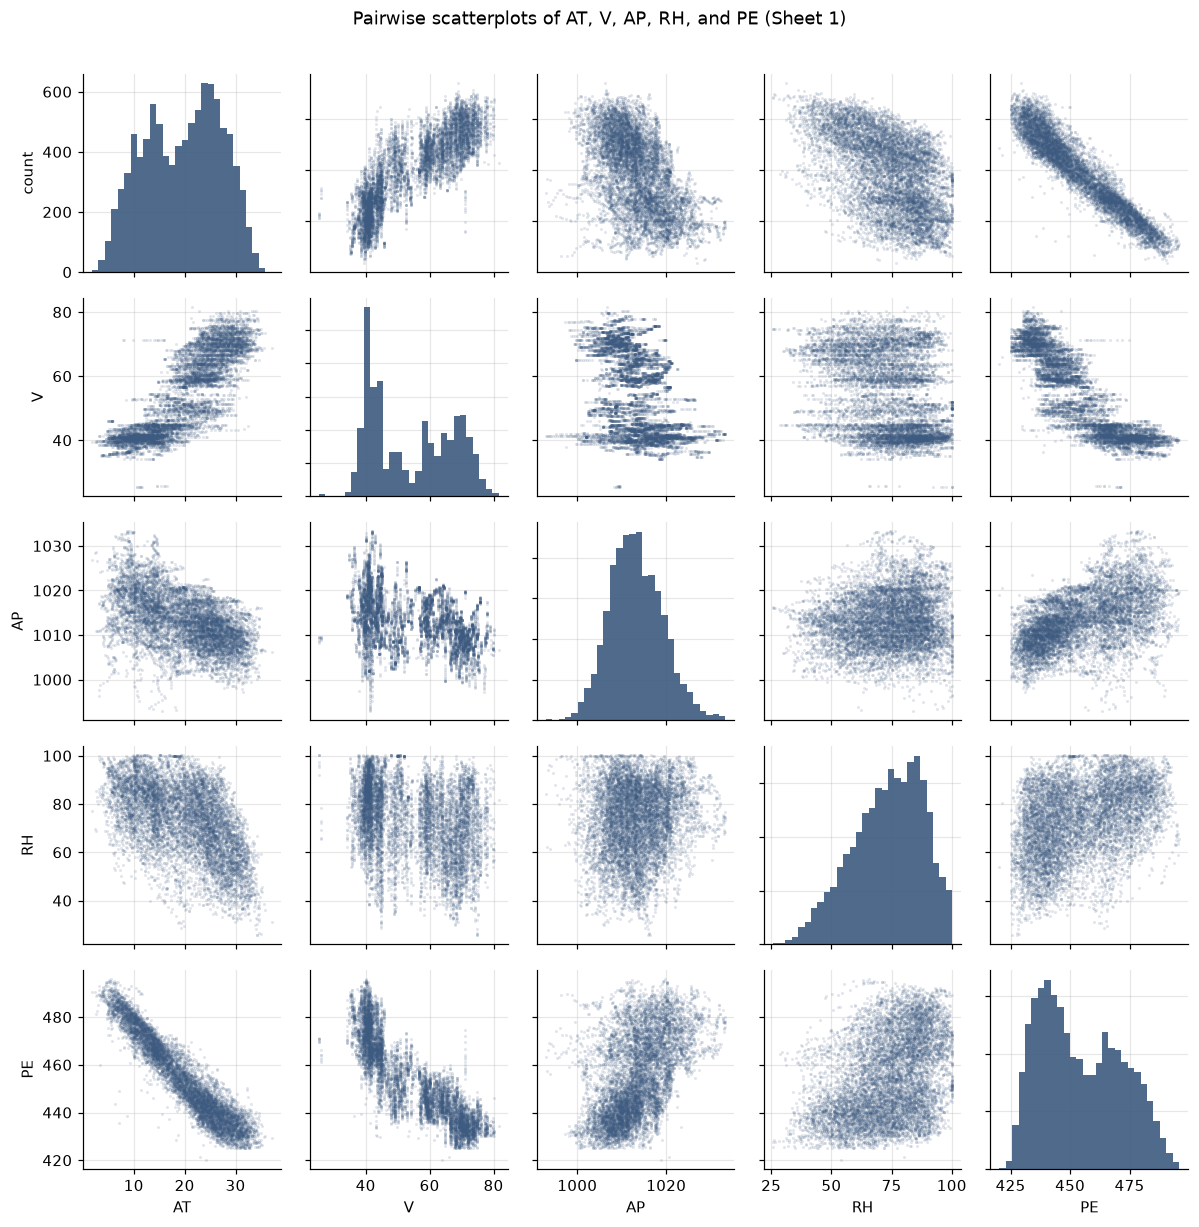

Correlations:
       AT      V     AP     RH     PE
AT  1.000  0.844 -0.508 -0.543 -0.948
V   0.844  1.000 -0.414 -0.312 -0.870
AP -0.508 -0.414  1.000  0.100  0.518
RH -0.543 -0.312  0.100  1.000  0.390
PE -0.948 -0.870  0.518  0.390  1.000


In [3]:
columns = PREDICTORS + [TARGET]
fig, axes = plt.subplots(5, 5, figsize=(11, 11))
for i, y_name in enumerate(columns):
    for j, x_name in enumerate(columns):
        ax = axes[i, j]
        if i == j:
            ax.hist(df[x_name], bins=28, color="#3d5a80", alpha=0.9)
        else:
            ax.scatter(
                df[x_name],
                df[y_name],
                s=4,
                alpha=0.15,
                c="#3d5a80",
                linewidths=0,
                rasterized=True,
            )
        if i == len(columns) - 1:
            ax.set_xlabel(x_name)
        else:
            ax.set_xticklabels([])
        if i == j and j == 0:
            ax.set_ylabel("count")
        elif j == 0:
            ax.set_ylabel(y_name)
        else:
            ax.set_yticklabels([])
fig.suptitle("Pairwise scatterplots of AT, V, AP, RH, and PE (Sheet 1)", y=1.01)
fig.tight_layout()
plt.show()

print("Correlations:")
print(df.corr().round(3))

The plots and the correlations agree.

- **AT and PE** form a tight downward cloud (correlation −0.95). Hotter ambient air goes with lower electrical output, and the cloud is close to a straight line with a slight bend.
- **V and PE** also slope downward (correlation −0.87), with more scatter than AT. V takes only a limited set of values, so the panels involving V appear in horizontal or vertical bands.
- The histograms of **AT and PE each have two peaks**. Cooler hours and higher output sit in one peak; hotter hours and lower output sit in the other.
- **AP and PE** slope upward, but the cloud is wide (correlation 0.52).
- **RH and PE** have only a mild upward drift (correlation 0.39).
- Among the predictors, **AT and V move together** (correlation 0.84). AT is also moderately negatively related to AP and to RH. AP and RH are almost unrelated (correlation 0.10).

So a simple regression on AT will look very strong, but AT and V carry a lot of the same information. That overlap will matter when all four predictors are put in one model.

#### (b.iii) Numerical summaries

In [4]:
summary = pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "range": df.max() - df.min(),
    "first quartile": df.quantile(0.25),
    "third quartile": df.quantile(0.75),
})
summary["interquartile range"] = summary["third quartile"] - summary["first quartile"]
summary = summary[
    ["mean", "median", "range", "first quartile", "third quartile", "interquartile range"]
]
summary.round(3)

,mean,median,range,first quartile,third quartile,interquartile range
AT,19.651,20.345,35.30,13.510,25.72,12.210
V,54.306,52.080,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,74.60,63.328,84.83,21.502
PE,454.365,451.550,75.50,439.750,468.43,28.680


PE sits near 454 MW, with an interquartile range of about 29 MW. AT and RH are spread out relative to their typical values. AP is compressed: the whole sample covers only about 40 mbar around 1,013 mbar. Means and medians are close for every variable, so none of the distributions is extremely skewed.

### (c) Simple linear regression

For each predictor \(X\), the model is

\[
\mathrm{PE} = \beta_0 + \beta_1 X + \varepsilon.
\]

A predictor has a statistically significant association with PE when the test of \(H_0: \beta_1 = 0\) has a p-value below 0.05. Points with an absolute externally studentized residual larger than 3 are flagged as outliers. The same model is then refit without those points, to see whether they drive the result.

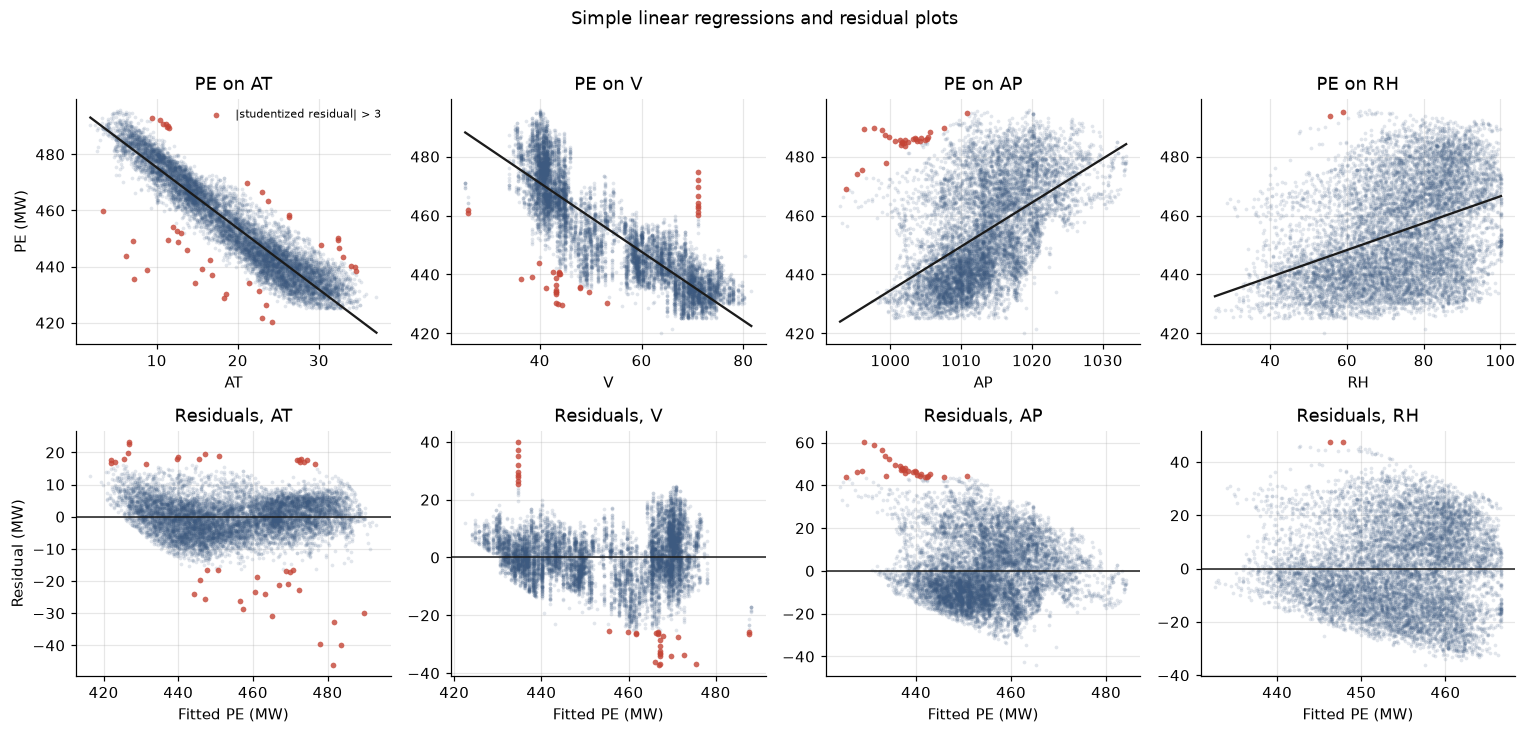

,intercept,slope,p-value,R²,outliers |student| > 3,slope without outliers
predictor,,,,,,
AT,497.0341,-2.1713,0.0,0.8989,42,-2.1802
V,517.8015,-1.1681,0.0,0.7565,33,-1.1769
AP,-1055.2610,1.4899,0.0,0.2688,30,1.5401
RH,420.9618,0.4557,0.0,0.1519,2,0.4564


In [5]:
simple_models = {}
simple_rows = []

fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
for i, name in enumerate(PREDICTORS):
    x = df[name]
    model = sm.OLS(df[TARGET], sm.add_constant(x)).fit()
    simple_models[name] = model
    influence = model.get_influence()
    student = influence.resid_studentized_external
    outlier = np.abs(student) > 3
    refit = sm.OLS(df.loc[~outlier, TARGET], sm.add_constant(x[~outlier])).fit()

    simple_rows.append({
        "predictor": name,
        "intercept": model.params["const"],
        "slope": model.params[name],
        "p-value": model.pvalues[name],
        "R²": model.rsquared,
        "outliers |student| > 3": int(outlier.sum()),
        "slope without outliers": refit.params[name],
    })

    ax = axes[0, i]
    ax.scatter(x[~outlier], df.loc[~outlier, TARGET], s=6, alpha=0.15, c="#3d5a80", linewidths=0, rasterized=True)
    ax.scatter(x[outlier], df.loc[outlier, TARGET], s=14, alpha=0.8, c="#c44536", linewidths=0, label="|studentized residual| > 3")
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, model.params["const"] + model.params[name] * x_line, color="#1b1b1b", linewidth=1.5)
    ax.set_xlabel(name)
    ax.set_ylabel("PE (MW)" if i == 0 else "")
    ax.set_title(f"PE on {name}")

    resid_ax = axes[1, i]
    fitted = model.fittedvalues
    resid_ax.scatter(fitted[~outlier], model.resid[~outlier], s=6, alpha=0.15, c="#3d5a80", linewidths=0, rasterized=True)
    resid_ax.scatter(fitted[outlier], model.resid[outlier], s=14, alpha=0.8, c="#c44536", linewidths=0)
    resid_ax.axhline(0, color="#1b1b1b", linewidth=1)
    resid_ax.set_xlabel("Fitted PE (MW)")
    resid_ax.set_ylabel("Residual (MW)" if i == 0 else "")
    resid_ax.set_title(f"Residuals, {name}")

axes[0, 0].legend(loc="upper right", fontsize=7, frameon=False)
fig.suptitle("Simple linear regressions and residual plots", y=1.02)
fig.tight_layout()
plt.show()

simple_table = pd.DataFrame(simple_rows).set_index("predictor")
simple_table.round(4)

All four associations are statistically significant. Every slope has a p-value far below 0.05, so in each one-predictor model we reject \(H_0: \beta_1 = 0\).

The strength of the association is not the same:

- **AT** has slope about −2.171 MW per °C and \(R^2 \approx 0.899\). This is the strongest simple model. Higher temperature goes with lower output.
- **V** has slope about −1.168 and \(R^2 \approx 0.757\). Higher exhaust vacuum goes with lower output.
- **AP** has slope about 1.490 and \(R^2 \approx 0.269\). Higher pressure goes with higher output, but most of the variation in PE is still left over.
- **RH** has slope about 0.456 and \(R^2 \approx 0.152\). The positive association is real at this sample size and weak as a predictor by itself.

The top row of plots shows the fitted line sitting on the main cloud. The residual plots for AT and V are not a formless band: the residuals still bend a little, which is a hint of nonlinearity to come back to in part (f). AP and RH leave a wide residual cloud, matching their low \(R^2\).

Outliers, counted as |studentized residual| > 3: 42 hours for AT, 33 for V, 30 for AP, and 2 for RH. Refitting without them moves the slopes only slightly (AT from −2.171 to −2.180, V from −1.168 to −1.177, AP from 1.490 to 1.540, RH from 0.456 to 0.456), and every association stays significant. There is no information that these hours are recording errors; they are plausible full-load hours. **I would not remove them** for any of the four regressions.

### (d) Multiple linear regression

The model with every predictor at once is

\[
\mathrm{PE} = \beta_0 + \beta_{\mathrm{AT}}\mathrm{AT} + \beta_V V + \beta_{\mathrm{AP}}\mathrm{AP} + \beta_{\mathrm{RH}}\mathrm{RH} + \varepsilon.
\]

For predictor \(j\), the hypothesis \(H_0: \beta_j = 0\) asks whether that predictor still has a linear association with PE after the other three are held fixed.

In [6]:
multiple = sm.OLS(df[TARGET], sm.add_constant(df[PREDICTORS])).fit()
print(multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:24:19   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

We can reject \(H_0: \beta_j = 0\) for **all four predictors**. Every p-value is below 0.001. The model \(R^2\) is about 0.929, higher than the best simple model (AT, 0.899), so the other predictors add some information beyond temperature.

The coefficients, in MW per unit of the predictor, are about **AT −1.978, V −0.234, AP 0.062, RH −0.158**. The sign of RH has flipped relative to its simple regression. That result is taken up in part (e).

The condition number is large mainly because AP is near 1,000 while the other predictors are much smaller, and because AT and V are correlated. The coefficient estimates are still precise: their standard errors are small next to the coefficients themselves.

### (e) Simple coefficients compared with multiple coefficients

Each predictor is one point. The horizontal coordinate is its slope from part (c). The vertical coordinate is its slope from part (d).

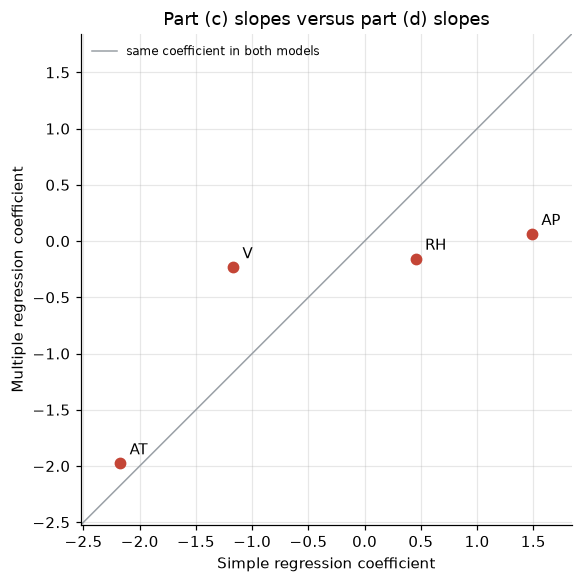

,simple slope,multiple slope,change
AT,-2.1713,-1.9775,0.1938
V,-1.1681,-0.2339,0.9342
AP,1.4899,0.0621,-1.4278
RH,0.4557,-0.1581,-0.6137


In [7]:
simple_slopes = np.array([simple_models[name].params[name] for name in PREDICTORS])
multiple_slopes = np.array([multiple.params[name] for name in PREDICTORS])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
limits = np.array([simple_slopes, multiple_slopes])
lo = limits.min() - 0.35
hi = limits.max() + 0.35
ax.plot([lo, hi], [lo, hi], color="#9aa0a6", linewidth=1, label="same coefficient in both models")
ax.scatter(simple_slopes, multiple_slopes, s=45, c="#c44536", zorder=3)
for name, x_val, y_val in zip(PREDICTORS, simple_slopes, multiple_slopes):
    ax.annotate(name, (x_val, y_val), textcoords="offset points", xytext=(6, 6))
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Simple regression coefficient")
ax.set_ylabel("Multiple regression coefficient")
ax.set_title("Part (c) slopes versus part (d) slopes")
ax.legend(frameon=False, fontsize=8)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()

pd.DataFrame({
    "simple slope": simple_slopes,
    "multiple slope": multiple_slopes,
    "change": multiple_slopes - simple_slopes,
}, index=PREDICTORS).round(4)

AT stays close to the diagonal: its slope moves from −2.171 to −1.978. The other three predictors move a lot.

- **V** shrinks from −1.168 to −0.234. V and AT are strongly correlated, so much of the simple V association was temperature showing up in vacuum. Once AT is in the model, vacuum has a smaller remaining association.
- **AP** shrinks from 1.490 to 0.062. Its simple association was partly standing in for the temperature and vacuum patterns it is correlated with.
- **RH** changes sign, from +0.456 to −0.158. In the raw data, humid hours tend to be cooler, and cooler hours produce more power, so humidity looks helpful on its own. After temperature is held fixed, higher humidity is associated with slightly lower output.

All four predictors remain statistically significant in both analyses. What changes is the size, and for RH the direction, once the predictors are adjusted for each other.

### (f) Nonlinear association

For each predictor separately, the cubic model is

\[
\mathrm{PE} = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon.
\]

There is evidence of a nonlinear association if the square or the cube is significant, or, more cleanly, if the cubic model fits better than the straight line by a partial F test.

The polynomial is fit in deviations from the predictor's mean,

\[
\mathrm{PE} = \beta_0 + \beta_1 (X - \bar X) + \beta_2 (X - \bar X)^2 + \beta_3 (X - \bar X)^3 + \varepsilon.
\]

This is the same family of curves as the formula in the prompt. Powers of raw ambient pressure are numerically unstable here: AP is near 1,013, so AP cubed is about \(10^9\), and the raw design matrix has a condition number around \(10^{15}\). Centering keeps the fitted curve and the F test the same while making the coefficients computable.

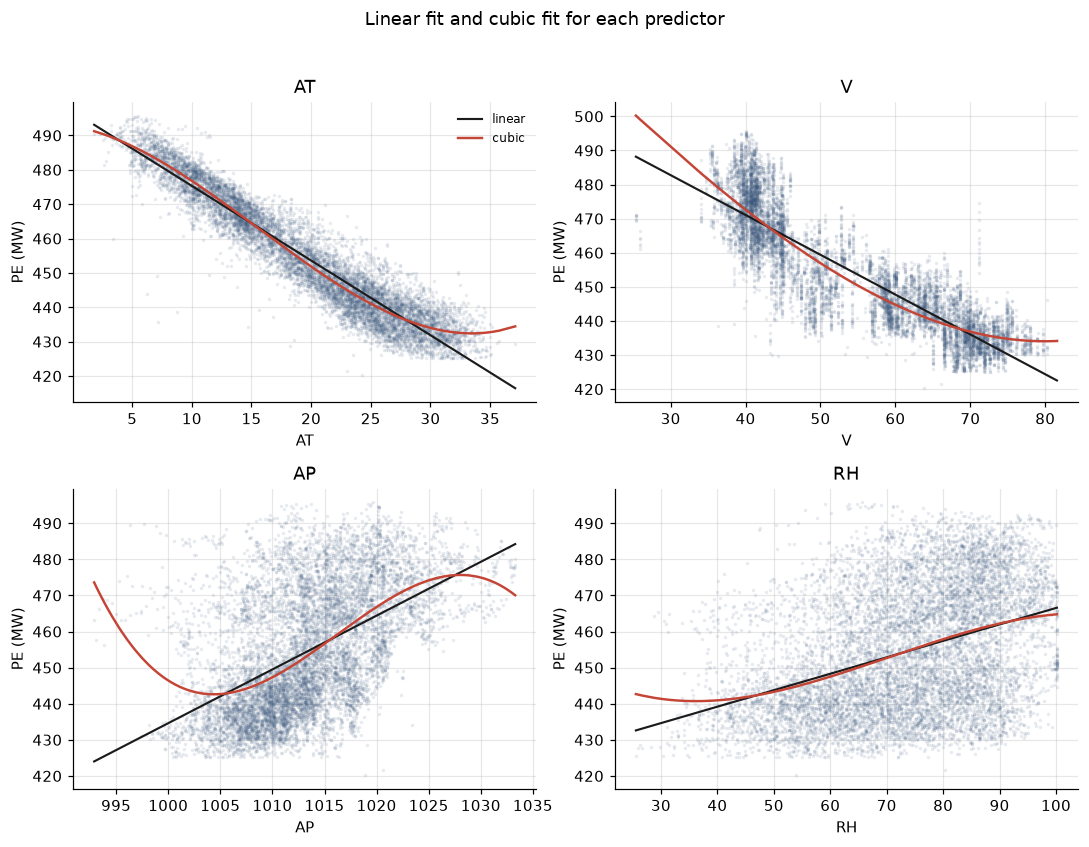

,quadratic coefficient,quadratic p-value,cubic coefficient,cubic p-value,linear R²,cubic R²,partial F p-value
predictor,,,,,,,
AT,0.032554,3.311808e-231,0.002675,3.652185e-110,0.898948,0.911883,3.478379e-285
V,0.019177,8.977010e-131,0.000134,1.373489e-02,0.756518,0.775022,7.040304e-165
AP,0.044238,2.192722e-46,-0.004991,2.123338e-67,0.268769,0.297543,4.209145e-84
RH,-0.001325,1.013949e-01,-0.000152,1.440279e-05,0.151939,0.153743,3.799622e-05


In [8]:
cubic_rows = []
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
for ax, name in zip(axes.ravel(), PREDICTORS):
    x = df[name]
    linear = simple_models[name]
    centered = x - x.mean()
    design = pd.DataFrame({"x": centered, "x2": centered ** 2, "x3": centered ** 3})
    cubic = sm.OLS(df[TARGET], sm.add_constant(design)).fit()
    comparison = sm.stats.anova_lm(linear, cubic)
    cubic_rows.append({
        "predictor": name,
        "quadratic coefficient": cubic.params["x2"],
        "quadratic p-value": cubic.pvalues["x2"],
        "cubic coefficient": cubic.params["x3"],
        "cubic p-value": cubic.pvalues["x3"],
        "linear R²": linear.rsquared,
        "cubic R²": cubic.rsquared,
        "partial F p-value": comparison["Pr(>F)"].iloc[1],
    })

    order = np.argsort(x.to_numpy())
    x_sorted = x.to_numpy()[order]
    ax.scatter(x, df[TARGET], s=5, alpha=0.12, c="#3d5a80", linewidths=0, rasterized=True)
    ax.plot(x_sorted, linear.fittedvalues.to_numpy()[order], color="#1b1b1b", linewidth=1.4, label="linear")
    ax.plot(x_sorted, cubic.fittedvalues.to_numpy()[order], color="#c44536", linewidth=1.6, label="cubic")
    ax.set_xlabel(name)
    ax.set_ylabel("PE (MW)")
    ax.set_title(name)

axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Linear fit and cubic fit for each predictor", y=1.02)
fig.tight_layout()
plt.show()

cubic_table = pd.DataFrame(cubic_rows).set_index("predictor")
cubic_table

Yes. The cubic model fits better than the straight line for **every predictor**. Each partial F test has a p-value far below 0.05.

- **AT:** both the square and the cube are significant. \(R^2\) rises from 0.899 to 0.912. The red curve bends away from the straight line at the hot and cool ends.
- **V:** both the square and the cube are significant (cube p ≈ 0.014). \(R^2\) rises from 0.757 to 0.775. In the dense part of the cloud the red curve flattens at high vacuum, which the straight line misses. At the lowest vacuum values, where hours are scarce, the cubic swings above the data.
- **AP:** both extra terms are significant. \(R^2\) rises from 0.269 to 0.298. Through the middle of the pressure range the cubic stays close to the straight line. The sharp bends are at the two ends, where few hours fall. The gain in fit is real, and a share of it comes from those thin tails.
- **RH:** the cube is significant (p ≈ 0.000014) and the square is not (p ≈ 0.10). \(R^2\) only moves from 0.152 to 0.154. The red curve stays close to the straight line across the cloud.

AT and V remain the associations that matter most for prediction. They are already nearly linear, and the cubic term tightens the fit. AP's cubic is statistically clear and visually driven by the tails. RH is only slightly curved.

### (g) Pairwise interactions

The model includes the four main effects and all six pairwise products. This question asks about the interaction coefficients, not the main effects. Those product coefficients are the rows named `AT:V`, `AT:AP`, and so on.

In [9]:
interaction_formula = "PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH"
interaction = sm.OLS.from_formula(interaction_formula, data=df).fit()
interaction_names = ["AT:V", "AT:AP", "AT:RH", "V:AP", "V:RH", "AP:RH"]
interaction_table = pd.DataFrame({
    "coefficient": interaction.params[interaction_names],
    "p-value": interaction.pvalues[interaction_names],
    "significant at 0.05": interaction.pvalues[interaction_names] < ALPHA,
})
print(f"Model R² = {interaction.rsquared:.4f}")
interaction_table

Model R² = 0.9363


,coefficient,p-value,significant at 0.05
AT:V,0.020971,3.333358e-117,True
AT:AP,0.001759,4.520509e-01,False
AT:RH,-0.005230,1.216944e-10,True
V:AP,0.006812,2.877026e-07,True
V:RH,0.000839,8.619366e-02,False
AP:RH,-0.001612,3.360557e-02,True


Yes. Four of the six interactions are statistically significant at the 0.05 level:

- **AT:V**, **AT:RH**, and **V:AP** have p-values far below 0.05.
- **AP:RH** is significant as well (p ≈ 0.034).
- **AT:AP** (p ≈ 0.45) and **V:RH** (p ≈ 0.086) are not significant.

The model \(R^2\) is about 0.936, compared with 0.929 for the main-effects model in part (d). Interactions are detectable. The largest of them is AT:V: the association between vacuum and output depends on the temperature. Adding the products only slightly raises the share of variance explained, because AT already accounts for most of it.

### (h) Does a richer linear model predict better?

The data are split once, at random, into 70% training rows and 30% test rows (`random_state=42`). Both models are fit on the training rows only, and mean squared error is computed on both parts.

1. **Baseline:** PE on AT, V, AP, and RH.
2. **Expanded, then reduced:** all four main effects, all six pairwise interactions, and all four squares. Insignificant terms are removed one at a time by p-value.

Two rules make that removal honest:

- **Centering.** Squares and products are built after subtracting the training-set mean of each predictor. A main-effect coefficient is then the slope at a typical hour. Without centering, the main-effect test asks what happens when ambient pressure is 0 mbar, which never occurs, and the p-values are the wrong test to drive deletion.
- **Hierarchy.** A main effect is kept while any square or interaction that uses it is still in the model. An interaction is not removed as a side effect of deleting its ingredients, and the ingredients are not deleted while the interaction remains. At each step, the removable term with the largest p-value above 0.05 is dropped, and the model is refit. Selection uses the training rows only.

In [10]:
train, test = train_test_split(df, test_size=0.30, random_state=RANDOM_STATE)
print(f"Training rows: {len(train)}")
print(f"Test rows: {len(test)}")

baseline = sm.OLS.from_formula("PE ~ AT + V + AP + RH", data=train).fit()


def make_design(frame, terms, center):
    centered = frame[PREDICTORS] - center
    columns = {}
    for term in terms:
        if term in PREDICTORS:
            columns[term] = centered[term].to_numpy()
        elif term.endswith("^2"):
            base = term[:-2]
            columns[term] = np.square(centered[base].to_numpy())
        else:
            left, right = term.split(":")
            columns[term] = centered[left].to_numpy() * centered[right].to_numpy()
    return pd.DataFrame(columns, index=frame.index)


def parents(term):
    if term in PREDICTORS:
        return []
    if term.endswith("^2"):
        return [term[:-2]]
    return term.split(":")


def fit_terms(frame, terms, center):
    design = make_design(frame, terms, center)
    return sm.OLS(frame[TARGET], sm.add_constant(design)).fit()


center = train[PREDICTORS].mean()
terms = (
    PREDICTORS
    + [f"{name}^2" for name in PREDICTORS]
    + ["AT:V", "AT:AP", "AT:RH", "V:AP", "V:RH", "AP:RH"]
)
removal_log = []
while True:
    fitted = fit_terms(train, terms, center)
    pvalues = fitted.pvalues.drop(labels="const")
    locked = set()
    for term in terms:
        locked.update(parents(term))
    removable = [term for term in terms if term not in locked and pvalues[term] > ALPHA]
    if not removable:
        break
    drop = max(removable, key=lambda term: pvalues[term])
    removal_log.append({"dropped": drop, "p-value": pvalues[drop]})
    terms.remove(drop)

reduced = fit_terms(train, terms, center)
print("Dropped terms:")
display(pd.DataFrame(removal_log))
print("Terms kept:", terms)


def mse_pair(model, terms_used, center_used):
    scores = {}
    for label, part in [("train", train), ("test", test)]:
        if terms_used is None:
            prediction = model.predict(part)
        else:
            design = sm.add_constant(make_design(part, terms_used, center_used), has_constant="add")
            prediction = model.predict(design)
        scores[label] = mean_squared_error(part[TARGET], prediction)
    return scores


baseline_mse = mse_pair(baseline, None, None)
reduced_mse = mse_pair(reduced, terms, center)
mse_table = pd.DataFrame({
    "train MSE": [baseline_mse["train"], reduced_mse["train"]],
    "test MSE": [baseline_mse["test"], reduced_mse["test"]],
}, index=["All four predictors", "Reduced quadratic and interaction model"])
mse_table.round(3)

Training rows: 6697
Test rows: 2871
Dropped terms:


,dropped,p-value
0,V:RH,0.867382
1,V^2,0.607733
2,V:AP,0.357826


Terms kept: ['AT', 'V', 'AP', 'RH', 'AT^2', 'AP^2', 'RH^2', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']


,train MSE,test MSE
All four predictors,20.581,21.24
Reduced quadratic and interaction model,17.891,18.66


The extra terms help, by a modest amount.

| Model | Train MSE | Test MSE |
|---|---:|---:|
| AT + V + AP + RH | 20.58 | 21.24 |
| Reduced model with squares and interactions | 17.89 | 18.66 |

On the training data the procedure drops **V:RH**, **V²**, and **V:AP**, in that order. Everything kept has a training p-value below 0.05, including all four main effects, the squares of AT, AP, and RH, and the interactions AT:V, AT:AP, AT:RH, and AP:RH.

Train and test errors are close to each other inside each model, so the reduced model is not simply memorizing the training hours. Test MSE falls from 21.24 to 18.66. In root-mean-square units that is about 4.61 MW versus 4.32 MW, against hourly output that averages about 454 MW. The richer linear model is better. Most of the predictable structure was already in the four main effects, especially AT.

### (i) K-nearest-neighbor regression

KNN regression is run on the same 70/30 split, for every \(k\) from 1 to 100. The raw version uses AT, V, AP, and RH as recorded. The normalized version subtracts the training mean and divides by the training standard deviation of each predictor, then applies those same shifts to the test rows. The \(k\) reported for each version is the one with the smallest test MSE. The plots show training and test error against \(1/k\).

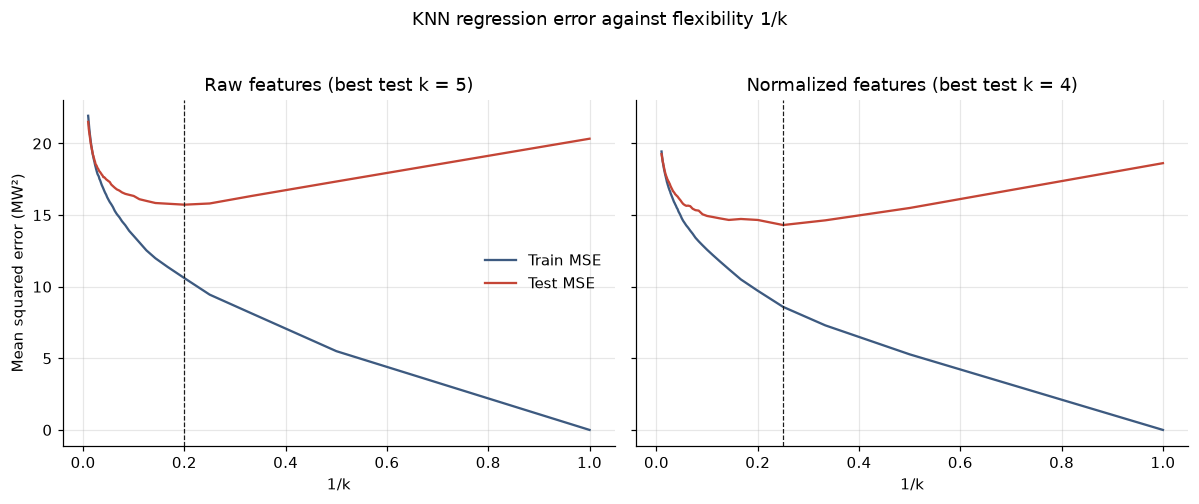

,best k,train MSE,test MSE
features,,,
Raw features,5,10.601,15.727
Normalized features,4,8.591,14.306


In [11]:
y_train = train[TARGET].to_numpy()
y_test = test[TARGET].to_numpy()
raw_train = train[PREDICTORS].to_numpy()
raw_test = test[PREDICTORS].to_numpy()
scaler = StandardScaler().fit(raw_train)
feature_sets = {
    "Raw features": (raw_train, raw_test),
    "Normalized features": (scaler.transform(raw_train), scaler.transform(raw_test)),
}

k_values = np.arange(1, 101)
knn_curves = {}
knn_summary = []
for label, (x_train, x_test) in feature_sets.items():
    train_mse = []
    test_mse = []
    for k in k_values:
        knn = KNeighborsRegressor(n_neighbors=int(k), algorithm="kd_tree")
        knn.fit(x_train, y_train)
        train_mse.append(mean_squared_error(y_train, knn.predict(x_train)))
        test_mse.append(mean_squared_error(y_test, knn.predict(x_test)))
    train_mse = np.asarray(train_mse)
    test_mse = np.asarray(test_mse)
    best_k = int(k_values[np.argmin(test_mse)])
    knn_curves[label] = (train_mse, test_mse, best_k)
    knn_summary.append({
        "features": label,
        "best k": best_k,
        "train MSE": train_mse[best_k - 1],
        "test MSE": test_mse[best_k - 1],
    })

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, label in zip(axes, feature_sets):
    train_mse, test_mse, best_k = knn_curves[label]
    ax.plot(1 / k_values, train_mse, color="#3d5a80", label="Train MSE")
    ax.plot(1 / k_values, test_mse, color="#c44536", label="Test MSE")
    ax.axvline(1 / best_k, color="#1b1b1b", linewidth=0.8, linestyle="--")
    ax.set_xlabel("1/k")
    ax.set_title(f"{label} (best test k = {best_k})")
axes[0].set_ylabel("Mean squared error (MW²)")
axes[0].legend(frameon=False)
fig.suptitle("KNN regression error against flexibility 1/k", y=1.03)
fig.tight_layout()
plt.show()

pd.DataFrame(knn_summary).set_index("features").round(3)

The best raw model uses **k = 5** (train MSE 10.60, test MSE 15.73). The best normalized model uses **k = 4** (train MSE 8.59, test MSE 14.31).

In both panels, training error is 0 at \(k = 1\), the right-hand end where \(1/k = 1\), because each training hour is its own nearest neighbor. Training error rises as one moves left and \(k\) gets larger, because the prediction is an average of more neighbors. Test error is high at that flexible right-hand end, lowest near \(k = 4\) or \(k = 5\), and rises again toward \(k = 100\).

Normalized features give the lower test error. On the raw scale, relative humidity and exhaust vacuum have larger standard deviations (about 14.6 and 12.7) than temperature and pressure (about 7.5 and 5.9), so Euclidean distance mostly reflects RH and V. Scaling puts the four predictors on comparable footing. The improvement is real and not huge: test MSE 14.31 versus 15.73.

### (j) KNN compared with the best linear model

The linear model with the smaller test error in part (h) is the reduced quadratic-and-interaction regression. The KNN model with the smaller test error in part (i) is normalized features with \(k = 4\).

In [12]:
comparison = pd.DataFrame({
    "train MSE": [
        baseline_mse["train"],
        reduced_mse["train"],
        knn_summary[0]["train MSE"],
        knn_summary[1]["train MSE"],
    ],
    "test MSE": [
        baseline_mse["test"],
        reduced_mse["test"],
        knn_summary[0]["test MSE"],
        knn_summary[1]["test MSE"],
    ],
    "test RMSE (MW)": np.sqrt([
        baseline_mse["test"],
        reduced_mse["test"],
        knn_summary[0]["test MSE"],
        knn_summary[1]["test MSE"],
    ]),
}, index=[
    "Linear, four predictors",
    "Linear, reduced squares and interactions",
    f"KNN raw, k = {knn_summary[0]['best k']}",
    f"KNN normalized, k = {knn_summary[1]['best k']}",
])
comparison.round(3)

,train MSE,test MSE,test RMSE (MW)
"Linear, four predictors",20.581,21.240,4.609
"Linear, reduced squares and interactions",17.891,18.660,4.320
"KNN raw, k = 5",10.601,15.727,3.966
"KNN normalized, k = 4",8.591,14.306,3.782


Normalized KNN with \(k = 4\) has the lower test error: **14.31** against **18.66** for the best linear model. The test root-mean-square error is about 3.78 MW against 4.32 MW.

That gap fits the earlier sections. Parts (f) and (g) already showed bends and interactions. A global model with squares and pairwise products captures the main ones and stops there. KNN can follow local curvature that those terms miss, which is why its test MSE is lower. The training error of the KNN (8.59) is well below its test error (14.31), so some of the flexibility at \(k = 4\) is fitting noise, but the test comparison still favors KNN.

The linear model remains the one that says *how* output moves: about −2 MW per extra degree of temperature after the other variables are accounted for, with smaller adjustments for vacuum, pressure, humidity, and a few products and squares. KNN does not produce those coefficients. For prediction on hours like these, the normalized KNN is the more accurate of the two. For explaining the plant, the reduced linear model is the useful one. The practical difference is moderate next to the 17 MW standard deviation of PE.

## 2. ISLR 2.4.1

For each situation, a flexible method (one that can follow complicated shapes, at the cost of higher variance) is compared with an inflexible method (one that stays close to a simple form, such as a straight line).

**(a) The sample size \(n\) is extremely large, and the number of predictors \(p\) is small.**

Flexible should perform better. A large sample keeps the variance of a flexible fit under control, and the small number of predictors means the method is not searching a huge space. The flexible fit can pick up bends that a rigid fit would miss, without paying much of a variance penalty.

**(b) The number of predictors \(p\) is extremely large, and the number of observations \(n\) is small.**

Flexible should perform worse. There are many ways to bend a fit and only a few rows to estimate it from, so the flexible method fits accidental patterns in those rows. An inflexible method estimates fewer quantities and usually has smaller test error in this regime.

**(c) The relationship between the predictors and the response is highly nonlinear.**

Flexible should perform better. An inflexible method is biased when the true curve bends sharply: it cannot get close to that curve no matter how large the sample is. Flexibility is spent here on reducing that bias.

**(d) The variance of the error terms, \(\sigma^2 = \mathrm{Var}(\varepsilon)\), is extremely high.**

Flexible should perform worse. A large \(\sigma^2\) means the response is noisy around the true relationship. A flexible method has enough freedom to chase that noise. A less flexible method smooths through it and typically predicts better.

## 3. ISLR 2.4.7

The training set has six observations, three predictors, and a color response. The new point is \((X_1, X_2, X_3) = (0, 0, 0)\). Distance is ordinary Euclidean distance.

| Obs. | \(X_1\) | \(X_2\) | \(X_3\) | \(Y\) |
|---|---:|---:|---:|---|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | −1 | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

In [13]:
observations = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"],
}, index=np.arange(1, 7))
observations.index.name = "Obs."
test_point = np.array([0.0, 0.0, 0.0])
distance = np.sqrt(((observations[["X1", "X2", "X3"]] - test_point) ** 2).sum(axis=1))
knn_table = observations.copy()
knn_table["Euclidean distance"] = distance
knn_table.round(4)

,X1,X2,X3,Y,Euclidean distance
Obs.,,,,,
1,0,3,0,Red,3.0000
2,2,0,0,Red,2.0000
3,0,1,3,Red,3.1623
4,0,1,2,Green,2.2361
5,-1,0,1,Green,1.4142
6,1,1,1,Red,1.7321


**(a) Distances to \((0,0,0)\).**

\[
\begin{align*}
d_1 &= \sqrt{0^2 + 3^2 + 0^2} = 3, \\
d_2 &= \sqrt{2^2 + 0^2 + 0^2} = 2, \\
d_3 &= \sqrt{0^2 + 1^2 + 3^2} = \sqrt{10} \approx 3.162, \\
d_4 &= \sqrt{0^2 + 1^2 + 2^2} = \sqrt{5} \approx 2.236, \\
d_5 &= \sqrt{(-1)^2 + 0^2 + 1^2} = \sqrt{2} \approx 1.414, \\
d_6 &= \sqrt{1^2 + 1^2 + 1^2} = \sqrt{3} \approx 1.732.
\end{align*}
\]

**(b) Prediction with \(K = 1\).**

The nearest neighbor is observation 5, at distance \(\sqrt{2}\). Its color is Green, so the prediction is **Green**.

**(c) Prediction with \(K = 3\).**

The three nearest observations are 5 (Green, \(\sqrt{2}\)), 6 (Red, \(\sqrt{3}\)), and 2 (Red, \(2\)). Red has two votes and Green has one, so the prediction is **Red**.

**(d) Highly nonlinear Bayes boundary.**

The best \(K\) should be **small**. A small \(K\) uses only the nearest observations, so the decision boundary can bend locally. A large \(K\) averages over a wide neighborhood and pulls the boundary toward a smoother shape. A highly nonlinear Bayes boundary calls for the more flexible, small-\(K\) fit.